In [6]:
import numpy as np
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap
from datasets import load_from_disk
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from infomap import Infomap
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import accuracy_score, f1_score, adjusted_rand_score, normalized_mutual_info_score

# =====================================================================
# BƯỚC 1: TẢI DATASET & VECTOR ĐẶC TRƯNG ĐÃ ĐƯỢC TIỀN XỬ LÝ (FEATURES.NPY)
# =====================================================================
print("1. Đang tải đặc trưng tiền xử lý từ features.npy...")
X_features = np.load('features.npy')
print(f"✔️ Đã tải ma trận đặc trưng: {X_features.shape}")

print("2. Đang tải dataset ImageNet-Hard từ local...")
ds = load_from_disk('./data/imagenet-hard')
labels_all = np.array([item[0] for item in ds['label']], dtype=np.int64)
print(f"✔️ Đã tải nhãn tương ứng. Kích thước: {labels_all.shape}")

# Chia Train/Test (80% Train, 20% Test) theo đúng random_state=42 của test_efficient
indices = list(range(len(ds)))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)
print(f"✔️ Chia tập dữ liệu thành công:")
print(f"   -> Số lượng Train: {len(train_idx)} | Test: {len(test_idx)}")

X_train = X_features[train_idx]
X_test = X_features[test_idx]
y_train = labels_all[train_idx]
y_test = labels_all[test_idx]

1. Đang tải đặc trưng tiền xử lý từ features.npy...
✔️ Đã tải ma trận đặc trưng: (10980, 256)
2. Đang tải dataset ImageNet-Hard từ local...
✔️ Đã tải nhãn tương ứng. Kích thước: (10980,)
✔️ Chia tập dữ liệu thành công:
   -> Số lượng Train: 8784 | Test: 2196


In [14]:
# =====================================================================
# BƯỚC 2: GRID SEARCH TÌM THAM SỐ TỐI ƯU (K-NEIGHBORS & MARKOV TIME)
# =====================================================================
k_candidates = [10, 15, 20, 25, 30]
markov_candidates = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8]
threshold = 0.5

best_nmi = -1.0
best_accuracy = -1.0
best_k = 0
best_m_time = 0.0
best_num_clusters = 0

print("="*85)
print(f"BẮT ĐẦU NESTED GRID SEARCH TRÊN TẬP TRAIN")
print(f"K-Neighbors candidates : {k_candidates}")
print(f"Markov Time candidates : {markov_candidates}")
print("="*85)
print(f"{'k':<5} | {'Markov':<8} | {'NMI':<8} | {'ARI':<8} | {'Accuracy':<9} | {'Số Cụm':<8} | {'Thời gian'}")
print("-" * 85)

# Hàm phụ trợ đối xạ nhãn dùng thuật toán Hungarian trên tập Train để tính Accuracy trực tiếp trong lúc Grid Search
def evaluate_clustering(communities, true_labels):
    n_communities = int(communities.max()) + 1
    n_classes = int(true_labels.max()) + 1
    cost_matrix = np.zeros((n_communities, n_classes))

    for i in range(len(communities)):
        cost_matrix[communities[i], true_labels[i]] += 1

    row_ind, col_ind = linear_sum_assignment(-cost_matrix)
    mapping = {int(r): int(c) for r, c in zip(row_ind, col_ind)}
    predicted = np.array([mapping.get(int(c), 0) for c in communities])
    
    acc = accuracy_score(true_labels, predicted)
    ari = adjusted_rand_score(true_labels, communities)
    nmi = normalized_mutual_info_score(true_labels, communities, average_method='arithmetic')
    return acc, ari, nmi

total_start_time = time.time()

for k in k_candidates:
    t_graph = time.time()
    
    # Xây dựng đồ thị k-NN từ đặc trưng tập Train
    knn_sparse = kneighbors_graph(X_train, n_neighbors=k, mode='distance', metric='cosine', n_jobs=-1)
    knn_sparse.data = 1.0 - knn_sparse.data
    knn_sparse.data[knn_sparse.data < threshold] = 0
    knn_sparse.eliminate_zeros()
    
    rows, cols = knn_sparse.nonzero()
    weights = knn_sparse.data
    
    for m in markov_candidates:
        t_cluster = time.time()
        
        # Cấu hình InfoMap
        params = f"--two-level --num-trials 10 --markov-time {m} --silent"
        im = Infomap(params)
        
        for i, j, w in zip(rows, cols, weights):
            im.add_link(i, j, w)
            
        im.run()
        
        # Trích xuất nhãn dự đoán
        y_pred = np.zeros(len(X_train), dtype=int)
        for node in im.tree:
            if node.is_leaf:
                y_pred[node.node_id] = node.module_id
                
        # Đánh giá hiệu suất
        acc, ari, nmi = evaluate_clustering(y_pred, y_train)
        num_clusters = len(np.unique(y_pred))
        
        exec_time = time.time() - t_cluster
        print(f"{k:<5} | {m:<8.1f} | {nmi:<8.4f} | {ari:<8.4f} | {acc:<9.4f} | {num_clusters:<8} | {exec_time:.2f}s")
        
        # Cập nhật tham số tốt nhất (Ưu tiên theo NMI tương tự test_efficient)
        if nmi > best_nmi:
            best_nmi = nmi
            best_accuracy = acc
            best_k = k
            best_m_time = m
            best_num_clusters = num_clusters

    print("-" * 85)

total_time = time.time() - total_start_time
print("\n" + "-"*30)
print("KẾT QUẢ TỐI ƯU HÓA TOÀN DIỆN TRÊN TẬP TRAIN ")
print(f"K_Neighbors tối ưu (Best k)    : {best_k}")
print(f"Markov Time tối ưu (Best M)    : {best_m_time}")
print(f"NMI cao nhất trên tập Train    : {best_nmi:.4f}")
print(f"Accuracy tương ứng (Train)     : {best_accuracy:.4f}")
print(f"Số lượng cụm dự đoán           : {best_num_clusters}")
print(f"Tổng thời gian Grid Search     : {total_time:.2f} giây")
print("-"*30)

BẮT ĐẦU NESTED GRID SEARCH TRÊN TẬP TRAIN
K-Neighbors candidates : [10, 15, 20, 25, 30]
Markov Time candidates : [0.5, 0.8, 1.0, 1.2, 1.5, 1.8]
k     | Markov   | NMI      | ARI      | Accuracy  | Số Cụm   | Thời gian
-------------------------------------------------------------------------------------
10    | 0.5      | 0.7819   | 0.1812   | 0.3437    | 1530     | 3.62s
10    | 0.8      | 0.7283   | 0.1677   | 0.3423    | 674      | 2.88s
10    | 1.0      | 0.7061   | 0.1428   | 0.3231    | 522      | 2.54s
10    | 1.2      | 0.6868   | 0.0919   | 0.2988    | 443      | 2.26s
10    | 1.5      | 0.6621   | 0.0770   | 0.2733    | 357      | 2.19s
10    | 1.8      | 0.6437   | 0.0729   | 0.2585    | 313      | 2.03s
-------------------------------------------------------------------------------------
15    | 0.5      | 0.7832   | 0.1863   | 0.3406    | 1897     | 4.27s
15    | 0.8      | 0.7102   | 0.1483   | 0.3204    | 589      | 3.20s
15    | 1.0      | 0.6848   | 0.1258   | 0.3007   

In [13]:
# =====================================================================
# BƯỚC 3: HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH VỚI THAM SỐ TỐT NHẤT (BEST PARAMS)
# =====================================================================
print(f"1. Đang xây dựng đồ thị k-NN cho TOÀN BỘ DATASET với k={best_k}...")
# Để mô hình học bán giám sát tốt nhất, ta tạo đồ thị k-NN chung cho toàn bộ dataset,
# sau đó dùng nhãn của tập Train để map các cụm và đánh giá độc lập trên tập Test.
knn_all = kneighbors_graph(X_features, n_neighbors=best_k, mode='distance', metric='cosine', n_jobs=-1)
knn_all.data = 1.0 - knn_all.data
knn_all.data[knn_all.data < threshold] = 0
knn_all.eliminate_zeros()

print("2. Đang thực thi Infomap tối ưu trên đồ thị...")
im_opt = Infomap(f"--two-level --num-trials 10 --markov-time {best_m_time} --silent")
rows, cols = knn_all.nonzero()
weights = knn_all.data
for i, j, w in zip(rows, cols, weights):
    im_opt.add_link(i, j, w)
im_opt.run()

# Lấy nhãn dự đoán cho tất cả các node
y_pred_all = np.zeros(len(X_features), dtype=int)
for node in im_opt.tree:
    if node.is_leaf:
        y_pred_all[node.node_id] = node.module_id

# Chia nhãn dự đoán thành phần Train và Test tương ứng
y_pred_train = y_pred_all[train_idx]
y_pred_test = y_pred_all[test_idx]

# =====================================================================
# ÁNH XẠ NHÃN BẰNG THUẬT TOÁN HUNGARIAN TRÊN TẬP TRAIN
# =====================================================================
print("3. Đang xây dựng bộ ánh xạ cộng đồng -> nhãn lớp thực tế (dựa trên tập Train)...")
n_communities = int(y_pred_all.max()) + 1
n_classes = int(labels_all.max()) + 1
cost_matrix = np.zeros((n_communities, n_classes))

for i in range(len(y_pred_train)):
    cost_matrix[y_pred_train[i], y_train[i]] += 1

row_ind, col_ind = linear_sum_assignment(-cost_matrix)
mapping = {int(r): int(c) for r, c in zip(row_ind, col_ind)}

# Dự đoán nhãn lớp thực tế
y_class_train = np.array([mapping.get(int(c), 0) for c in y_pred_train])
y_class_test = np.array([mapping.get(int(c), 0) for c in y_pred_test])

# Tính toán các chỉ số chất lượng đầy đủ
def full_evaluate(y_true, y_pred_class, y_pred_comm):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred_class),
        'F1-score' : f1_score(y_true, y_pred_class, average='weighted', zero_division=0),
        'ARI'      : adjusted_rand_score(y_true, y_pred_comm),
        'NMI'      : normalized_mutual_info_score(y_true, y_pred_comm)
    }

m_train = full_evaluate(y_train, y_class_train, y_pred_train)
m_test = full_evaluate(y_test, y_class_test, y_pred_test)

print(f"\n{'='*55}")
print(f" KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TỐI ƯU ")
print(f"{'='*55}")
print(f"🔹 Train Accuracy : {m_train['Accuracy']:.4f} | Test Accuracy : {m_test['Accuracy']:.4f}")
print(f"🔹 Train F1-score : {m_train['F1-score']:.4f} | Test F1-score : {m_test['F1-score']:.4f}")
print(f"🔹 Train ARI      : {m_train['ARI']:.4f} | Test ARI      : {m_test['ARI']:.4f}")
print(f"🔹 Train NMI      : {m_train['NMI']:.4f} | Test NMI      : {m_test['NMI']:.4f}")
print(f"🔹 Số lượng cụm   : {len(np.unique(y_pred_all))}")
print(f"{'='*55}")

1. Đang xây dựng đồ thị k-NN cho TOÀN BỘ DATASET với k=25...
2. Đang thực thi Infomap tối ưu trên đồ thị...
3. Đang xây dựng bộ ánh xạ cộng đồng -> nhãn lớp thực tế (dựa trên tập Train)...

 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TỐI ƯU 
🔹 Train Accuracy : 0.2966 | Test Accuracy : 0.2404
🔹 Train F1-score : 0.3621 | Test F1-score : 0.2819
🔹 Train ARI      : 0.1546 | Test ARI      : 0.1720
🔹 Train NMI      : 0.7988 | Test NMI      : 0.8687
🔹 Số lượng cụm   : 4407


1. Đang giảm chiều dữ liệu từ 256 chiều xuống 2 chiều bằng UMAP...


c:\Projects\ai_prj\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✔️ Ép chiều hoàn tất! Thời gian: 5.13s
2. Đang vẽ biểu đồ trực quan hóa Ground Truth vs Infomap Predictions...
✅ Biểu đồ đã được lưu thành công tại: ./data/infomap_umap_visualization.png


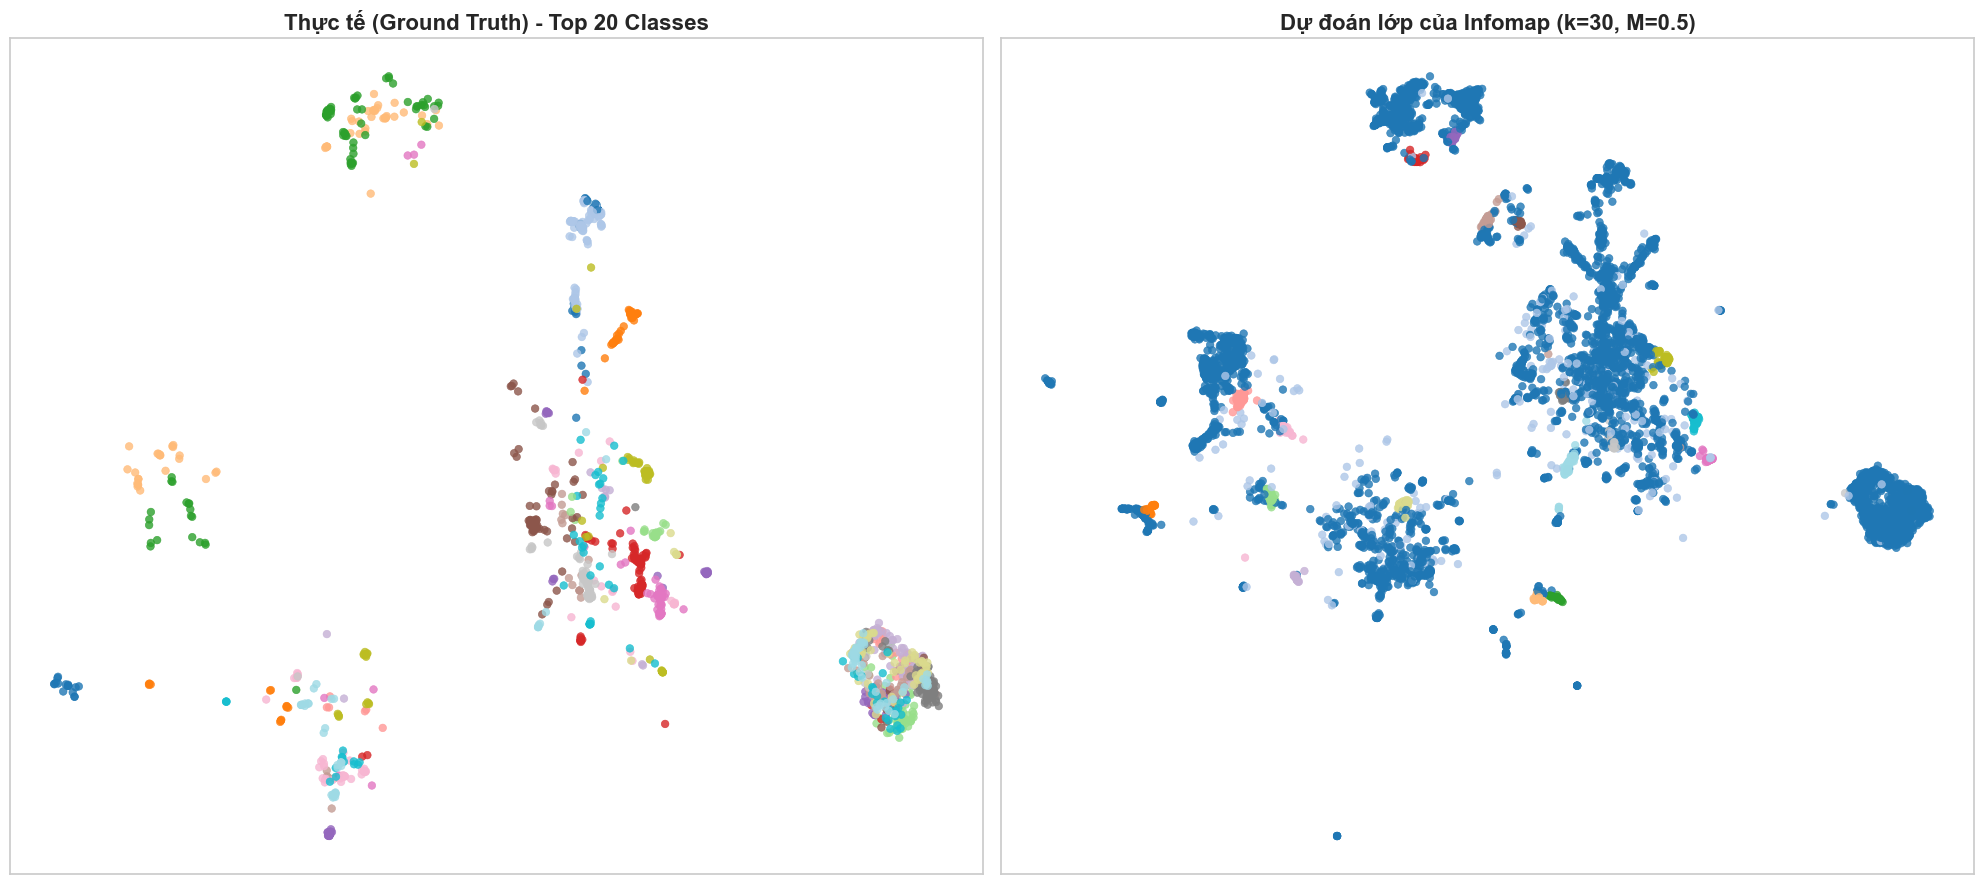

In [15]:
# =====================================================================
# BƯỚC 4: GIẢM CHIỀU DỮ LIỆU UMAP & TRỰC QUAN HÓA SIDE-BY-SIDE
# =====================================================================
print("1. Đang giảm chiều dữ liệu từ 256 chiều xuống 2 chiều bằng UMAP...")
t0_umap = time.time()
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
X_2d = reducer.fit_transform(X_features)
print(f"✔️ Ép chiều hoàn tất! Thời gian: {time.time() - t0_umap:.2f}s")

print("2. Đang vẽ biểu đồ trực quan hóa Ground Truth vs Infomap Predictions...")
top_n_classes = 20

# Hàm lọc Top N class nhiều ảnh nhất để vẽ tránh nhiễu
def get_top_n_mask(labels, n):
    unique, counts = np.unique(labels, return_counts=True)
    top_labels = unique[np.argsort(-counts)][:n]
    mask = np.isin(labels, top_labels)
    return mask, top_labels

mask_true, _ = get_top_n_mask(labels_all, top_n_classes)
# Lấy mapping dự đoán lớp cho tất cả các node để vẽ biểu đồ so sánh lớp trực quan
y_class_all = np.array([mapping.get(int(c), 0) for c in y_pred_all])
mask_pred, _ = get_top_n_mask(y_class_all, top_n_classes)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
sns.set_theme(style="whitegrid")

# Biểu đồ 1: Ground Truth
sns.scatterplot(
    x=X_2d[mask_true, 0], y=X_2d[mask_true, 1],
    hue=labels_all[mask_true],
    palette=sns.color_palette("tab20", n_colors=top_n_classes),
    s=30, alpha=0.8, edgecolor=None, ax=axes[0], legend=False
)
axes[0].set_title(f"Thực tế (Ground Truth) - Top {top_n_classes} Classes", fontsize=16, fontweight='bold')
axes[0].set_xticks([])
axes[0].set_yticks([])

# Biểu đồ 2: Infomap Predictions mapped
sns.scatterplot(
    x=X_2d[mask_pred, 0], y=X_2d[mask_pred, 1],
    hue=y_class_all[mask_pred],
    palette=sns.color_palette("tab20", n_colors=top_n_classes),
    s=30, alpha=0.8, edgecolor=None, ax=axes[1], legend=False
)
axes[1].set_title(f"Dự đoán lớp của Infomap (k={best_k}, M={best_m_time})", fontsize=16, fontweight='bold')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
os.makedirs('./data', exist_ok=True)
plt.savefig("./data/infomap_umap_visualization.png", dpi=300, bbox_inches='tight')
print("✅ Biểu đồ đã được lưu thành công tại: ./data/infomap_umap_visualization.png")
plt.show()

In [ ]:
# =====================================================================
# BƯỚC 5: CHẠY BASELINE VÀ SO SÁNH HIỆU QUẢ CẢI TIẾN
# =====================================================================
k_baseline = 15
print(f"1. Đang chạy mô hình Baseline với Infomap mặc định (k={k_baseline})...")
t0_base = time.time()

knn_base = kneighbors_graph(X_features, n_neighbors=k_baseline, mode='distance', metric='cosine', n_jobs=-1)
knn_base.data = 1.0 - knn_base.data
knn_base.data[knn_base.data < threshold] = 0
knn_base.eliminate_zeros()

# InfoMap mặc định
im_base = Infomap(silent=True, directed=False)
rows, cols = knn_base.nonzero()
weights = knn_base.data
for i, j, w in zip(rows, cols, weights):
    im_base.add_link(i, j, w)
im_base.run()

y_pred_base = np.zeros(len(X_features), dtype=int)
for node in im_base.tree:
    if node.is_leaf:
        y_pred_base[node.node_id] = node.module_id

y_pred_base_train = y_pred_base[train_idx]
y_pred_base_test = y_pred_base[test_idx]

# Map Hungarian trên tập Train cho mô hình Baseline
cost_matrix_base = np.zeros((int(y_pred_base.max()) + 1, n_classes))
for i in range(len(y_pred_base_train)):
    cost_matrix_base[y_pred_base_train[i], y_train[i]] += 1
row_ind_base, col_ind_base = linear_sum_assignment(-cost_matrix_base)
mapping_base = {int(r): int(c) for r, c in zip(row_ind_base, col_ind_base)}

y_class_base_test = np.array([mapping_base.get(int(c), 0) for c in y_pred_base_test])
m_base_test = full_evaluate(y_test, y_class_base_test, y_pred_base_test)

# So sánh sự khác biệt
acc_diff = m_test['Accuracy'] - m_base_test['Accuracy']
nmi_diff = m_test['NMI'] - m_base_test['NMI']

print(f"\n{'='*55}")
print(f"BẢNG SO SÁNH HIỆU SUẤT TRÊN TẬP TEST ")
print(f"{'='*55}")
print(f"{'Metric':<12} | {'Baseline (Mặc định)':<20} | {'Tối ưu (Grid Search)':<20} | {'Cải tiến':<10}")
print(f"-"*70)
print(f"{'Accuracy':<12} | {m_base_test['Accuracy']:<20.4f} | {m_test['Accuracy']:<20.4f} | {acc_diff*100:+.2f}%")
print(f"{'F1-score':<12} | {m_base_test['F1-score']:<20.4f} | {m_test['F1-score']:<20.4f} | {(m_test['F1-score']-m_base_test['F1-score'])*100:+.2f}%")
print(f"{'ARI':<12} | {m_base_test['ARI']:<20.4f} | {m_test['ARI']:<20.4f} | {(m_test['ARI']-m_base_test['ARI'])*100:+.2f}%")
print(f"{'NMI':<12} | {m_base_test['NMI']:<20.4f} | {m_test['NMI']:<20.4f} | {(m_test['NMI']-m_base_test['NMI'])*100:+.2f}%")
print(f"{'Số Cụm':<12} | {len(np.unique(y_pred_base)):<20} | {len(np.unique(y_pred_all)):<20} | {len(np.unique(y_pred_all)) - len(np.unique(y_pred_base)):+d}")
print(f"{'='*55}")

1. Đang chạy mô hình Baseline với Infomap mặc định (k=15)...

📊 BẢNG SO SÁNH HIỆU SUẤT TRÊN TẬP TEST 📊
Metric       | Baseline (Mặc định)  | Tối ưu (Grid Search) | Cải tiến  
----------------------------------------------------------------------
Accuracy     | 0.0260               | 0.2404               | +21.45%
F1-score     | 0.0205               | 0.2819               | +26.14%
ARI          | 0.0031               | 0.1720               | +16.89%
NMI          | 0.2161               | 0.8687               | +65.26%
Số Cụm       | 82                   | 4407                 | +4325



1. Đang tạo biểu đồ: Khám phá ngữ nghĩa các cụm ảnh do thuật toán tìm ra...
✅ Biểu đồ khám phá ngữ nghĩa đã được lưu tại: ./data/semantic_exploration.png


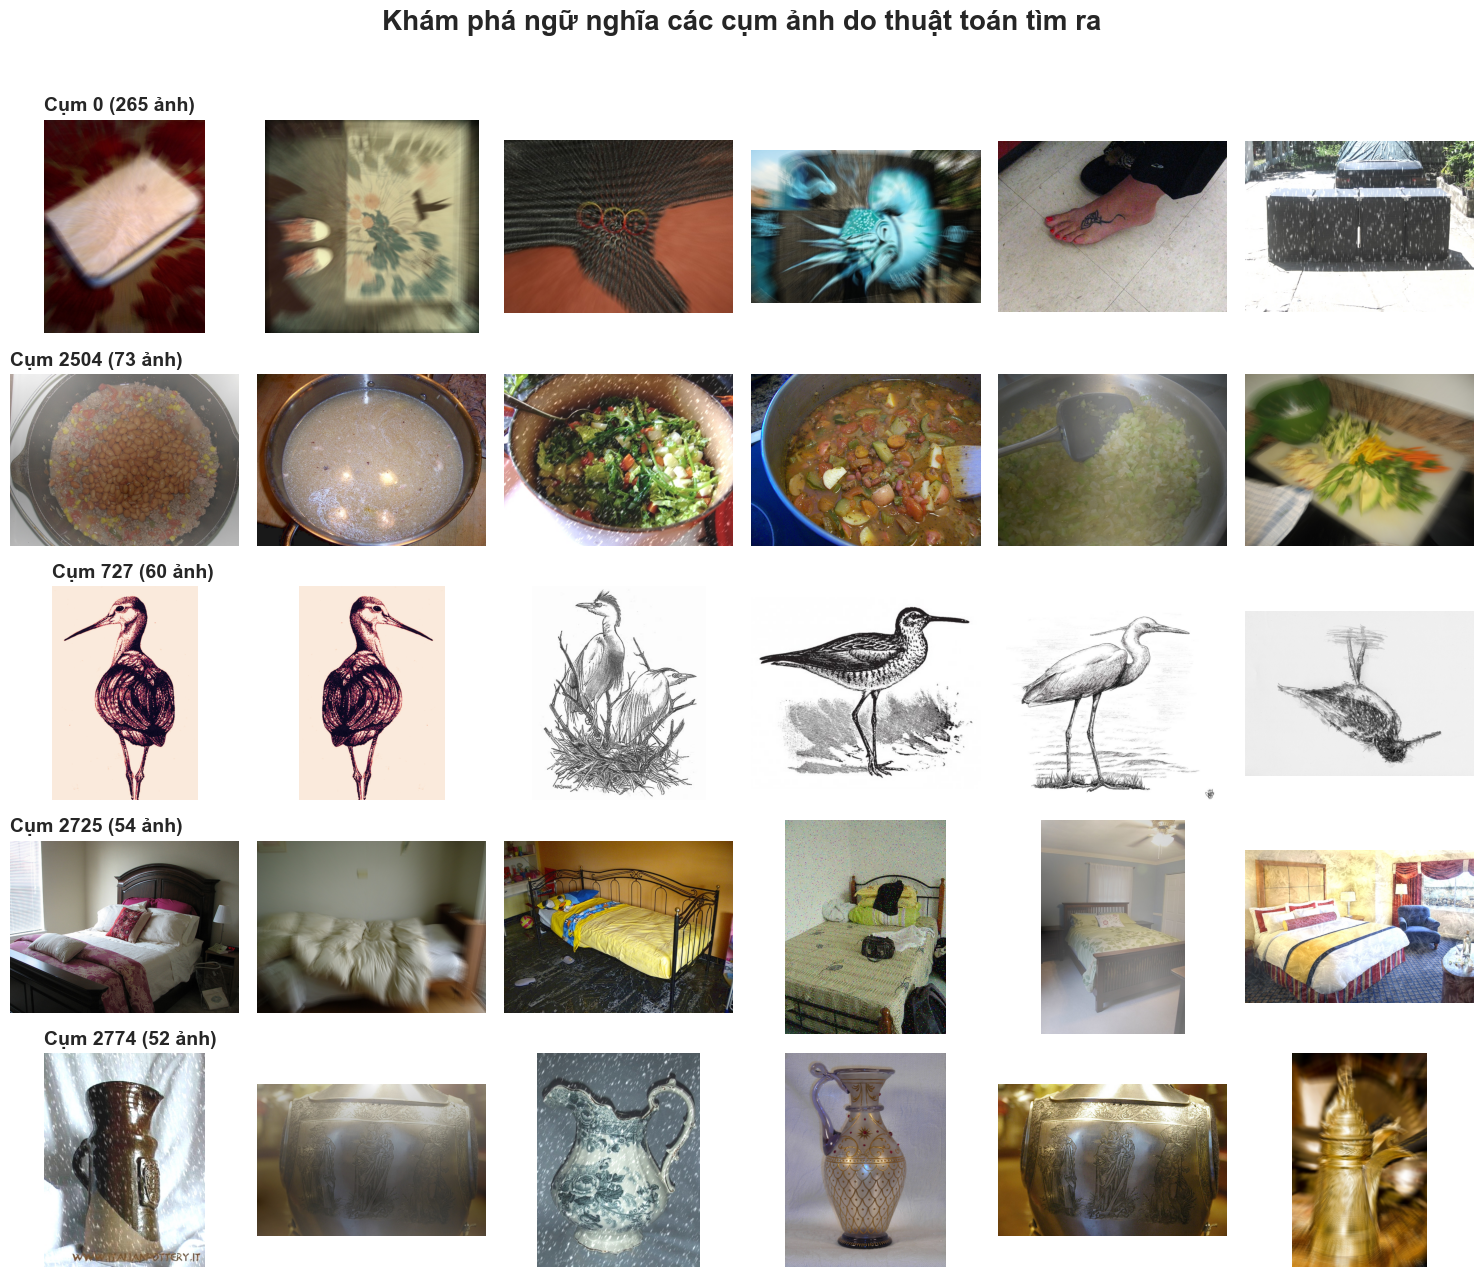

In [ ]:
# =====================================================================
# BƯỚC 6: KHÁM PHÁ NGỮ NGHĨA CÁC CỤM ẢNH (IMAGE GRID)
# =====================================================================
print("\n" + "="*85)
print("1. Đang tạo biểu đồ: Khám phá ngữ nghĩa các cụm ảnh do thuật toán tìm ra...")

num_top_clusters = 5    # Số cụm lớn nhất muốn hiển thị
images_per_cluster = 6  # Số ảnh đại diện cho mỗi cụm

# Đếm số lượng ảnh của từng cụm
unique_clusters, counts = np.unique(y_pred_all, return_counts=True)
top_cluster_indices = np.argsort(-counts)[:num_top_clusters]
top_clusters = unique_clusters[top_cluster_indices]

# Tạo biểu đồ lưới
fig, axes = plt.subplots(num_top_clusters, images_per_cluster, figsize=(15, 2.5 * num_top_clusters))
fig.suptitle("Khám phá ngữ nghĩa các cụm ảnh do thuật toán tìm ra", fontsize=20, fontweight='bold', y=1.02)

# Đặt seed để chọn ngẫu nhiên các ảnh giống nhau trong mỗi lần chạy
np.random.seed(42)

for i, cluster_id in enumerate(top_clusters):
    # Lấy vị trí (index) của các ảnh thuộc cụm cluster_id
    idx_in_cluster = np.where(y_pred_all == cluster_id)[0]
    
    # Chọn ngẫu nhiên vài ảnh từ cụm này để hiển thị
    selected_idx = np.random.choice(
        idx_in_cluster, 
        min(images_per_cluster, len(idx_in_cluster)), 
        replace=False
    )
    
    for j in range(images_per_cluster):
        ax = axes[i, j]
        ax.axis('off')
        if j < len(selected_idx):
            # Lấy ảnh thực tế từ dataset ImageNet-Hard
            # ds['image'] lưu trữ đối tượng ảnh (PIL.Image)
            img = ds['image'][int(selected_idx[j])]
            ax.imshow(img)
            
            # Chỉ ghi chú ở bức ảnh đầu tiên của mỗi hàng
            if j == 0:
                ax.set_title(f"Cụm {cluster_id} ({counts[top_cluster_indices[i]]} ảnh)", 
                             loc='left', fontsize=14, fontweight='bold')

plt.tight_layout()
output_path = "./data/semantic_exploration.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Biểu đồ khám phá ngữ nghĩa đã được lưu tại: {output_path}")
print("="*85)
